In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import argparse
import json
import sys
from sklearn import linear_model
import statsmodels.api as sm
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
#import shap
from scipy.interpolate import make_interp_spline

In [2]:
# Lectura de datos
## 2D

# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../data/Dataset 4, popup_screen_brazil.csv')

dim_2 = pd.read_csv('results/coordsU/Brasil_31_07_2024_12_07_21.csv')
dim_2 = pd.merge(userMetadata,dim_2,on='user_id')

**Se filtrará el autoreporte de politica de centro (5).**

In [3]:

dim_2 = dim_2[dim_2['politica']!=99].reset_index()
dim_2 = dim_2[dim_2['politica']!=3].reset_index()
dim_2 = dim_2.drop('index',axis=1)


In [4]:
dim_2['politica'].unique()

array([1, 2, 5, 4], dtype=int64)

In [5]:
def label_region(region):
    """
    Define un identificador para las regiones
    """
    if region=='PR':
        return 0
    if region=='RS':
        return 1
    elif region == 'MG':
        return 2
    elif region =='PE':
        return 3
    elif region =='GO':
        return 4
    elif region =='SC':
        return 5
    elif region =='AC':
        return 6
    elif region =='MS':
        return 7
    elif region =="PB":
        return 8
    elif region =='AL':
        return 9
    elif region =='BA':
        return 10
    elif region =='RJ':
        return 11
    elif region =='SP':
        return 12
    elif region =='DF':
        return 13
    elif region =='SE':
        return 14
    elif region =='ES':
        return 15
    elif region =='RN':
        return 16
    elif region =='RO':
        return 17
    elif region =='CE':
        return 18
    elif region =='AM':
        return 10
    elif region =='RR':
        return 20
    elif region =='MA':
        return 21
    elif region =='PA':
        return 22
    elif region =='PI':
        return 23


# Se asigna un valor binario a la columna 'sex', reemplazando 'Femenino' con 0 y 'Masculino' con 1.
dim_2['region'] = dim_2['region'].apply(lambda x:label_region(x))

## 2. Modelos de clasificación


**Los modelos de clasificación son herramientas esenciales para la automatización de decisiones basadas en datos en una variedad de campos, permitiendo la asignación precisa de elementos a categorías o clases.**

**En esta investigación, la categorización se establece de la siguiente manera:**

1. Categoría [0-4]: Izquierda
2. Categoría [6-10]: Derecha

**Además, también se realiza la clasificación en las siguientes categorías:**

1. Categoría [1]: Extrema Izquierda
2. Categoría [2]: Izquierda
3. Categoría [4]: Derecha
4. Categoría [5]: Extrema Derecha



In [6]:
# Definición de la función de etiquetado
def label(politica):
    """
    Asigna etiquetas a los valores de la variable 'politica' según ciertos rangos establecidos. 
    La etiqueta 0 representa [0,1,2] Extrema Izquierda
    La etiqueta 1 representa [3,4] Izquierda
    La etiqueta 2 representa [6,7] Derecha
    La etiqueta 3 representa [8,9,10] Extrema Derecha
    """
    if politica in [1]:
        label = 0
    elif politica in [2]:
        label = 1
    if politica in [4]:
        label = 2
    elif politica in [5]:
        label = 3
    return label


dim_2['politica classifier'] = dim_2['politica'].apply(lambda x: label(x))

**Se divide la base de datos en train y test**

In [7]:
# Labels son los valores que queremos predecir
labels_4 = dim_2['politica classifier']
labels_4 = np.array(labels_4)


# axis 1 se refiere a las columnas
features = dim_2.drop(['id', 'politica','level_0','location','zone','education','politica classifier','created_at', 'score', 'locale','universe'], axis=1)
feature_list = list(features.columns)
features = features.set_index('user_id')


# Dividimos los datos en conjuntos de entrenamiento y prueba
train_features_0, test_features_0, train_labels_4, test_labels_4 = train_test_split(features, labels_4, test_size=0.3, random_state=42)

train_features_1 = np.array(train_features_0)
test_features_1 = np.array(test_features_0)


# Escalado de características
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#scaler = StandardScaler()
train_features = scaler.fit_transform(train_features_1)
test_features = scaler.transform(test_features_1)
train_labels = [0 if x <= 1 else 1 for x in train_labels_4]
test_labels = [0 if x <= 1 else 1 for x in test_labels_4]


In [8]:
features.columns

Index(['age', 'sex', 'region', 'z1', 'z2'], dtype='object')

**2.1.4 Análisis** $z_1^2$, $z_2^2$, $z_1$ * $z_2$**coordenadas políticas (2d), edad, sexo y región (X) y auto reporte (Y: Izq-Der)**

In [9]:
""" Se añaden las coordenadas al cuadrado a la base de entrenamiento"""
# TRAIN
# Calcula las nuevas dimensiones
sexta_dimension = train_features_1[:, 3]**2
septima_dimension = train_features_1[:, 4]**2
octava_dimension = train_features_1[:, 3] * train_features_1[:, 4]

# Apila las nuevas dimensiones a la matriz original
new_train_features_1 = np.hstack((train_features_1, sexta_dimension.reshape(-1, 1), septima_dimension.reshape(-1, 1), octava_dimension.reshape(-1, 1)))

# TEST
# Calcula las nuevas dimensiones
sexta_dimension = test_features_1[:, 3]**2
septima_dimension = test_features_1[:, 4]**2
octava_dimension = test_features_1[:, 3] * test_features_1[:, 4]

# Apila las nuevas dimensiones a la matriz original
new_test_features_1 = np.hstack((test_features_1, sexta_dimension.reshape(-1, 1), septima_dimension.reshape(-1, 1), octava_dimension.reshape(-1, 1)))

scaler_1 = MinMaxScaler()
#scaler_1 = StandardScaler()
train_features_new = scaler_1.fit_transform(new_train_features_1)
test_features_new = scaler_1.transform(new_test_features_1)


### 2.2 Modelo de clasificación de Random Forest

**2.2.1 Análisis edad, sexo y región (X) y auto reporte (Y: Izq-Der)**

In [10]:
# Ajuste de la clasificación de Random Forest al conjunto de entrenamiento
model_socio = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)
model_socio.fit(train_features[:,0:3], train_labels)


# Predicción
y_pred_socio = model_socio.predict(test_features[:,0:3])


# Cálculo de recall y precision
precision = metrics.precision_score(test_labels, y_pred_socio,average='macro')
recall = metrics.recall_score(test_labels, y_pred_socio,average='macro')
f1_score= metrics.f1_score(test_labels, y_pred_socio,average='macro')
acc = metrics.accuracy_score(test_labels, y_pred_socio)



**2.2.1 Análisis coordenadas políticas (2d), edad, sexo y región (X) y auto reporte (Y: Izq-Der)**

In [11]:

# Ajuste de la clasificación de Random Forest al conjunto de entrenamiento
classifier = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)
classifier.fit(train_features, train_labels)

# Predicción de los resultados del conjunto de prueba
y_pred = classifier.predict(test_features)

# Cálculo de recall y precision
precision = metrics.precision_score(test_labels, y_pred,average='macro')
recall = metrics.recall_score(test_labels, y_pred,average='macro')
f1_score= metrics.f1_score(test_labels, y_pred,average='macro')
acc = metrics.accuracy_score(test_labels, y_pred)


print(acc)
#0.8209618400418192

0.8630952380952381


In [12]:
# Obtener los árboles del bosque
estimators = classifier.estimators_

# Obtener la profundidad de cada árbol
depths = [estimator.tree_.max_depth for estimator in estimators]

# Imprimir la profundidad de cada árbol
for i, depth in enumerate(depths):
    print(f"Árbol {i+1}: Profundidad máxima = {depth}")

Árbol 1: Profundidad máxima = 12
Árbol 2: Profundidad máxima = 14
Árbol 3: Profundidad máxima = 12
Árbol 4: Profundidad máxima = 9
Árbol 5: Profundidad máxima = 11
Árbol 6: Profundidad máxima = 9
Árbol 7: Profundidad máxima = 16
Árbol 8: Profundidad máxima = 14
Árbol 9: Profundidad máxima = 9
Árbol 10: Profundidad máxima = 11
Árbol 11: Profundidad máxima = 10
Árbol 12: Profundidad máxima = 13
Árbol 13: Profundidad máxima = 12
Árbol 14: Profundidad máxima = 11
Árbol 15: Profundidad máxima = 14
Árbol 16: Profundidad máxima = 10
Árbol 17: Profundidad máxima = 11
Árbol 18: Profundidad máxima = 10
Árbol 19: Profundidad máxima = 10
Árbol 20: Profundidad máxima = 9
Árbol 21: Profundidad máxima = 13
Árbol 22: Profundidad máxima = 9
Árbol 23: Profundidad máxima = 10
Árbol 24: Profundidad máxima = 11
Árbol 25: Profundidad máxima = 14
Árbol 26: Profundidad máxima = 10
Árbol 27: Profundidad máxima = 11
Árbol 28: Profundidad máxima = 9
Árbol 29: Profundidad máxima = 10
Árbol 30: Profundidad máxima 

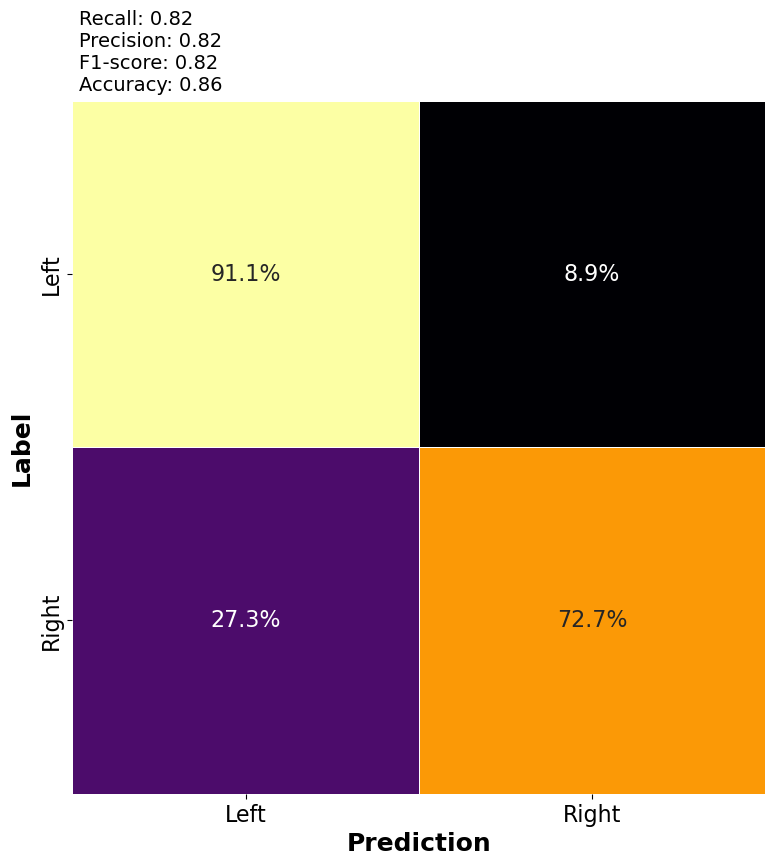

In [13]:
# Creación de la matriz de confusión
plt.figure(figsize=(9, 9))
matriz = confusion_matrix(test_labels, y_pred, normalize='true')
classes = ['Left', 'Right']
sns.heatmap(matriz, annot=True, fmt='.1%', linewidths=0.5, square=True, cmap='inferno', xticklabels=classes, yticklabels=classes, cbar=False,annot_kws={'size': 16})
plt.ylabel('Label', fontsize=18, fontweight='bold')
plt.xlabel('Prediction', fontsize=18, fontweight='bold')
all_sample_title = 'dim 2'
#plt.title(all_sample_title, size=15, fontweight='bold')


# Se imprimen métricas dentro de la figura con estilo "negrita"
metrics_text = f'Recall: {round(recall, 2)}\nPrecision: {round(precision, 2)}\nF1-score: {round(f1_score, 2)}\nAccuracy: {round(acc, 2)}'
plt.text(0.01, 1.07, metrics_text,  va='center', transform=plt.gca().transAxes, fontsize=14)

# Ajuste del tamaño de letra para las métricas
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Guardar la figura en la ruta 'figuras' con un título conveniente

plt.show()




In [14]:
# Export results
# Save the matrix as a file (e.g., .npz)
classes = ['Left', 'Right']
metrics = {'recall': recall, 'precision': precision, 'f1_score': f1_score, 'accuracy': acc}

np.savez("data_plots/confusion_matrix_data_Brasil.npz", matriz=matriz, classes=classes, metrics=metrics)

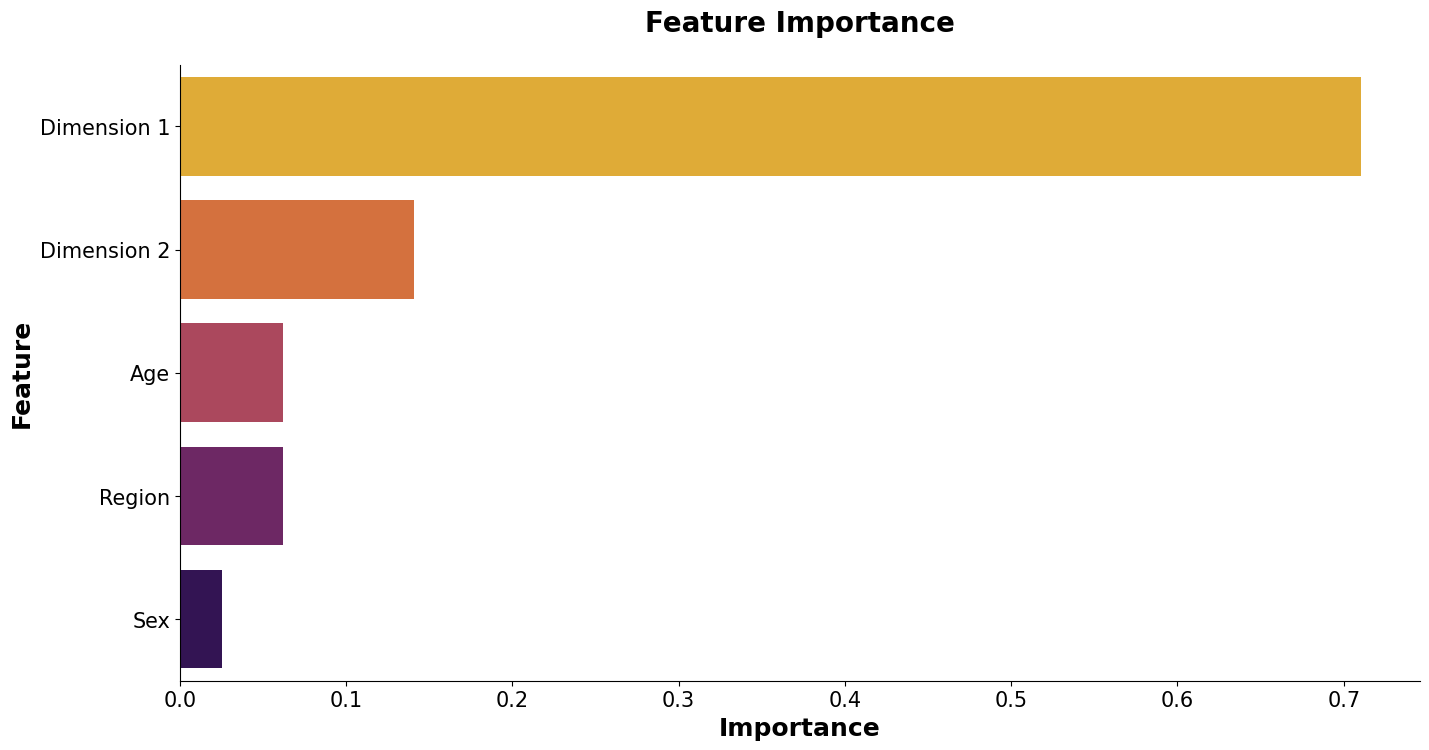

In [14]:
def hide_border(ax):
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


# Suponiendo que tienes tus datos de importancia de características y nombres de características
feature_importances = classifier.feature_importances_
feature_names = ['Age','Sex', 'Region', 'Dimension 1', 'Dimension 2']

# Obtener los índices ordenados de mayor a menor
sorted_indices = np.argsort(feature_importances)  # Orden descendente

# Reordenar los nombres de características y las importancias de características según los índices ordenados
sorted_feature_names = [feature_names[i] for i in sorted_indices]
sorted_feature_importances = [feature_importances[i] for i in sorted_indices]

# Crear un gráfico de barras para mostrar la importancia de las características ordenadas
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
colors = sns.color_palette('inferno', len(sorted_feature_importances))  # Obtener colores de la paleta 'inferno'
sns.barplot(y=sorted_feature_names, x=sorted_feature_importances, palette=colors, ax=ax)
plt.yticks(range(len(sorted_feature_importances)), sorted_feature_names, fontsize=15)
plt.xlabel('Importance', fontsize=18, fontweight='bold')
plt.ylabel('Feature', fontsize=18, fontweight='bold')
plt.setp(ax.get_xticklabels(), fontsize=15)
ax.set_title("Feature Importance", pad=24, fontweight=700, fontsize=20)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.gca().invert_yaxis()  # Invertir el eje y para que las características más importantes estén arriba
plt.show()


In [24]:
# Save the sorted feature importances to a CSV
export_data = pd.DataFrame({
    'Feature': sorted_feature_names,
    'Importance': sorted_feature_importances
})
export_data.to_csv('data_plots/feature_importance_brasil.csv', index=False)

In [15]:
#explainer = shap.TreeExplainer(classifier)
#shap_values = explainer.shap_values(test_features[0:145])
#shap.summary_plot(shap_values, test_features[0:145])

In [16]:
#df = pd.DataFrame(test_features[0:145], columns=feature_names)
#explainer = shap.Explainer(classifier, df)
#shap_values = explainer(df,check_additivity=False)

In [17]:
# Crear una figura y ejes
#fig, ax = plt.subplots()

#shap.plots.beeswarm(shap_values[:,:,1],show=False,color=plt.get_cmap("seismic"))
#plt.gcf().set_size_inches(7, 5)
# Modificar los nombres de los extremos del colorbar

# Modificar los nombres de los extremos del colorbar
#cax = plt.gcf().get_axes()[-1]  # Obtener la barra de colores
#cax.set_yticklabels(['Right Political party', 'Left Political party'])


#plt.savefig('figuras/Plot/shap value.png',dpi=299,bbox_inches = "tight")

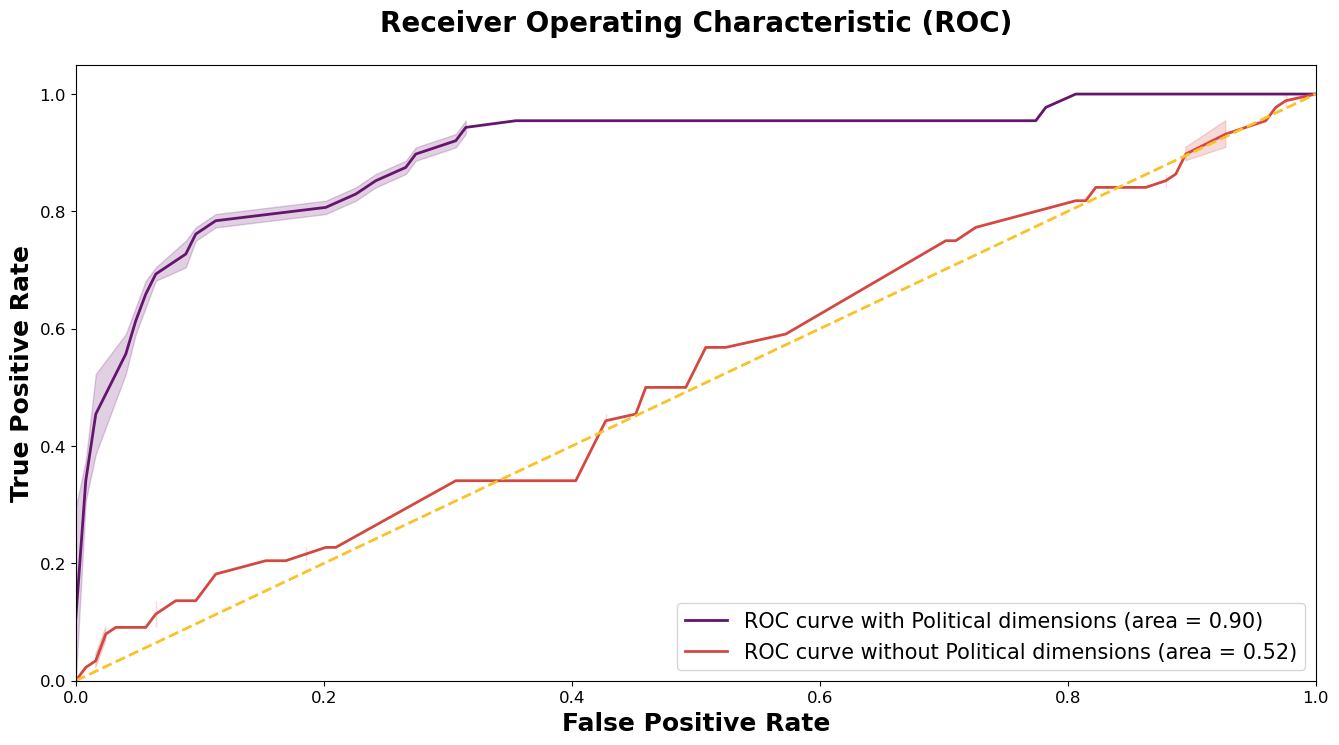

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Calcula la curva ROC
fpr_socio, tpr_socio, thresholds = roc_curve(test_labels, model_socio.predict_proba(test_features[:,0:3])[:,1])
roc_auc_socio = auc(fpr_socio, tpr_socio)


# Calcula la curva ROC
fpr, tpr, thresholds = roc_curve(test_labels, classifier.predict_proba(test_features)[:,1])
roc_auc = auc(fpr, tpr)

# Crear un gráfico de la curva ROC
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
sns.lineplot(x=fpr, y=tpr, color=sns.color_palette('inferno')[1], lw=2, label=f'ROC curve with Political dimensions (area = {roc_auc:.2f})')
sns.lineplot(x=fpr_socio, y=tpr_socio, color=sns.color_palette('inferno')[3], lw=2, label=f'ROC curve without Political dimensions (area = {roc_auc_socio:.2f})')

# Ajustes de la gráfica
plt.plot([0, 1], [0, 1], color=sns.color_palette('inferno')[5], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize = 19)
plt.yticks(fontsize = 19)
plt.xlabel('False Positive Rate', fontsize=18,fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=18,fontweight='bold')
ax.set_title("Receiver Operating Characteristic (ROC)", pad=24, fontweight=700, fontsize=20)
plt.legend(loc='lower right', fontsize=15)

# Aumentar el tamaño del texto
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('figuras/Plot/Receiver Operating Characteristic.png')
plt.show()


In [26]:
# Save ROC data with Political dimensions
roc_data = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr
})
roc_data.to_csv('data_plots/roc_with_political_Brasil.csv', index=False)

# Save ROC data without Political dimensions
roc_socio_data = pd.DataFrame({
    'FPR': fpr_socio,
    'TPR': tpr_socio
})
roc_socio_data.to_csv('data_plots/roc_without_political_Brasil.csv', index=False)

# Save AUC values
auc_data = pd.DataFrame({
    'Model': ['With Political Dimensions', 'Without Political Dimensions'],
    'AUC': [roc_auc, roc_auc_socio]
})
auc_data.to_csv('data_plots/roc_auc_values_Brasil.csv', index=False)

**Validación cruzada de 10 particiones**

In [16]:
from sklearn.model_selection import StratifiedKFold

# Definir el número de particiones
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Listas para almacenar los puntajes de validación cruzada y las predicciones
cv_scores = []
predictions = []
features = features.reset_index(drop=True)
a=0
for train_index, test_index in skf.split(features, labels_4):
    # Dividir los datos en entrenamiento y prueba
    X_train, X_test = features.iloc[train_index], features.iloc[test_index]
    y_train_fold, y_test_fold = labels_4[train_index], labels_4[test_index]

    # Escalar características
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    y_train_fold = [0 if x <= 1 else 1 for x in y_train_fold]
    y_test_fold = [0 if x <= 1 else 1 for x in y_test_fold]

    
    # Inicializar el clasificador y el escalador
    classifier = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)

    # Entrenar el clasificador
    classifier.fit(X_train_scaled, y_train_fold)

    # Calcular el puntaje de precisión en la partición de prueba
    test_predictions = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test_fold, test_predictions)
    cv_scores.append(accuracy)
    print(a)
    a=a+1


0
1
2
3
4
5
6
7
8
9


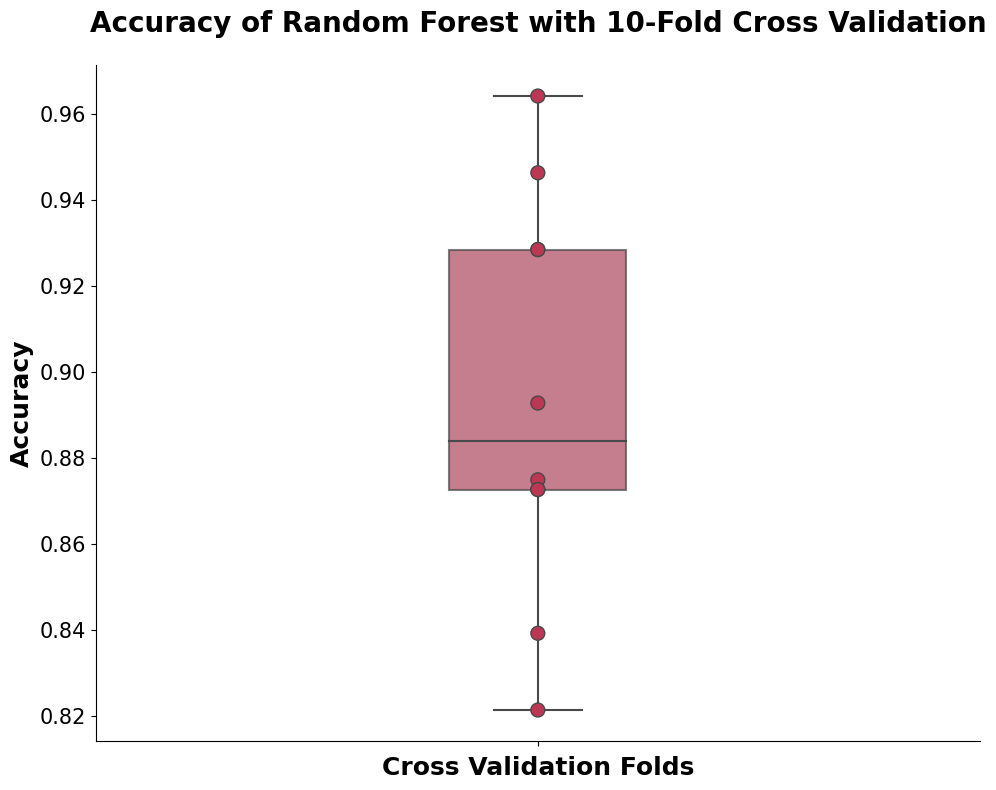

In [17]:

# Crear una figura
fig, ax = plt.subplots(1,1, figsize=(10,8))

# Plotear los resultados en un boxplot
sns.boxplot(y=cv_scores,palette='inferno',showfliers=False,ax=ax,boxprops={'alpha': 0.7},width = 0.2)
sns.stripplot(y=cv_scores,palette='inferno', dodge=True,ax=ax,size=10,jitter=0,linewidth=1)
#sns.boxplot(x=cv_scores, palette='viridis')
plt.yticks(fontsize = 15)
ax.set_xlabel('Cross Validation Folds',fontsize=18,fontweight='bold')
ax.set_ylabel('Accuracy',fontsize=18,fontweight='bold')
ax.set_title("Accuracy of Random Forest with 10-Fold Cross Validation",pad=24,fontweight=700,fontsize=20)
hide_border(ax)
# Mostrar la figura
plt.tight_layout()
#plt.savefig('figuras/Plot/Boxplot of SVM Accuracy with 10-Fold Cross Validation.png')
plt.show()

In [25]:
# Save cross-validation scores to a CSV file
cv_scores_df = pd.DataFrame({'CV_Scores': cv_scores})
cv_scores_df.to_csv('data_plots/cross_validation_scores_Brasil.csv', index=False)

**2.2.6 A continuación, procederemos a dividir el conjunto de pruebas en 10 particiones en función de la cantidad de votos considerando un análisis de** $z_1^2$, $z_2^2$, $z_1$ * $z_2$**coordenadas políticas (2d), edad, sexo y región (X) y auto reporte (Y: Izq-Der)****

In [18]:
# Creamos una instancia de RandomForestClassifier con los mejores parámetros encontrados
classifier = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)

classifier.fit(train_features_new, train_labels)
# Predicción de los resultados del conjunto de prueba
y_pred = classifier.predict(test_features_new)

# Cálculo de recall y precision
precision = metrics.precision_score(test_labels, y_pred,average='macro')
recall = metrics.recall_score(test_labels, y_pred,average='macro')
f1_score= metrics.f1_score(test_labels, y_pred,average='macro')
acc = metrics.accuracy_score(test_labels, y_pred)

  Votaciones  Precision    Recall  F1_score  Accuracy
0       1-14   0.675000  0.616667  0.590769  0.631579
1      15-21   0.833333  0.875000  0.828571  0.833333
2      22-37   0.925000  0.625000  0.659459  0.857143
3      38-55   1.000000  1.000000  1.000000  1.000000
4     56-100   0.950000  0.944444  0.944272  0.944444
5    105-287   0.716667  0.770833  0.737327  0.842105
6    295-427   0.750000  0.916667  0.787879  0.857143
7    430-618   0.875000  0.954545  0.904762  0.928571
8    630-980   0.791667  0.791667  0.791667  0.866667
9  1024-1192   1.000000  1.000000  1.000000  1.000000


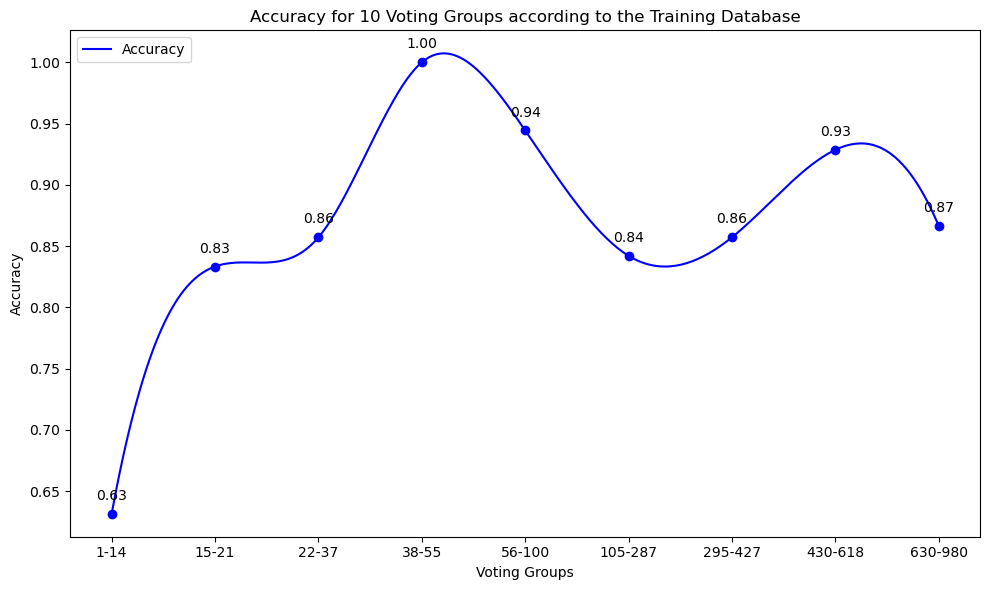

In [21]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from scipy.interpolate import make_interp_spline

# Lectura de archivo que contiene la cantidad de votaciones por usuario
with open('results/cantidad_votaciones_usuarios_primerciclo_Brazil.json', 'r') as archivo:
    datos = json.load(archivo)

df_votaciones = pd.DataFrame(list(datos.items()), columns=['user_id', 'votaciones'])

df_completo_train = pd.merge(train_features_0, df_votaciones, on='user_id')
df_completo_test = pd.merge(test_features_0.reset_index().reset_index(), df_votaciones, on='user_id')

# Ordenamos el DataFrame por la cantidad de votaciones
df_completo_train = df_completo_train.sort_values(by='votaciones')

# Calcular los percentiles en base al DataFrame de entrenamiento
percentiles = np.percentile(df_completo_train['votaciones'], np.arange(0, 101, 11))  # Dividir en 10 grupos

# Agregar una columna que indique a qué grupo pertenece cada fila en el DataFrame de entrenamiento
df_completo_train['percentile_group'] = np.searchsorted(percentiles, df_completo_train['votaciones'], side='right') - 1

# Dividir el DataFrame de entrenamiento en 10 grupos por percentil
grupos_por_percentil = [
    df_completo_train[df_completo_train['percentile_group'] == i]
    for i in range(len(percentiles))
]

# Inicializar metricas correctamente
metricas = pd.DataFrame(columns=['Votaciones', 'Precision', 'Recall', 'F1_score', 'Accuracy'])

# Recorrer los grupos de df_completo_train
for grupo in grupos_por_percentil:
    # Obtener las cotas máximas y mínimas de votaciones para el grupo actual
    cota_minima = grupo['votaciones'].min()
    cota_maxima = grupo['votaciones'].max()
    
    # Filtrar test_features en base a las cotas
    test_features_grupo = df_completo_test[
        (df_completo_test['votaciones'] >= cota_minima) &
        (df_completo_test['votaciones'] <= cota_maxima)
    ]
    
    # Aquí deberías tener tus datos de y_pred y test_labels relacionados con el grupo actual
    index = test_features_grupo['index'].to_list()
    
    if len(index) == 0:
        continue  # Evitar errores si no hay datos en test para este grupo
    
    y_pred_percentil = y_pred[index]
    test_labels_grupo = np.array(test_labels)[index]
    cotas = f"{int(cota_minima)}-{int(cota_maxima)}"

    # Cálculo de las métricas
    precision = metrics.precision_score(test_labels_grupo, y_pred_percentil, average='macro')
    recall = metrics.recall_score(test_labels_grupo, y_pred_percentil, average='macro')
    f1_score = metrics.f1_score(test_labels_grupo, y_pred_percentil, average='macro')
    acc = metrics.accuracy_score(test_labels_grupo, y_pred_percentil)

    # Agregar la fila usando loc[]
    metricas.loc[len(metricas)] = [cotas, precision, recall, f1_score, acc]

print(metricas)

# El último no tiene ejemplo en test así que irá de 1 a 9
metricas = metricas.iloc[0:9]

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Interpolar la curva para suavizarla
xnew = np.linspace(0, len(metricas['Accuracy']) - 1, 300)
spl = make_interp_spline(range(len(metricas['Accuracy'])), metricas['Accuracy'], k=3)
y_smooth = spl(xnew)

# Agregar la línea suavizada
plt.plot(xnew, y_smooth, label='Accuracy', color='blue')

# Agregar los puntos
plt.scatter(range(len(metricas['Accuracy'])), metricas['Accuracy'], color='blue', marker='o')

# Agregar los valores de accuracy encima de los puntos
for i, txt in enumerate(metricas['Accuracy']):
    plt.annotate(f'{txt:.2f}', (i, txt), textcoords="offset points", xytext=(0,10), ha='center')

plt.xticks(range(len(metricas)), metricas['Votaciones'])  # Cambiado a la columna 'Votaciones'
plt.xlabel("Voting Groups")
plt.ylabel('Accuracy')
plt.title("Accuracy for 10 Voting Groups according to the Training Database")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()



In [23]:
# Save the relevant columns to CSV
metricas[['Votaciones', 'Accuracy']].to_csv("data_plots/Groups_Accuracy_brazil.csv", index=False)
print("CSV file saved at data_plots/Groups_Accuracy.csv")

CSV file saved at data_plots/Groups_Accuracy.csv


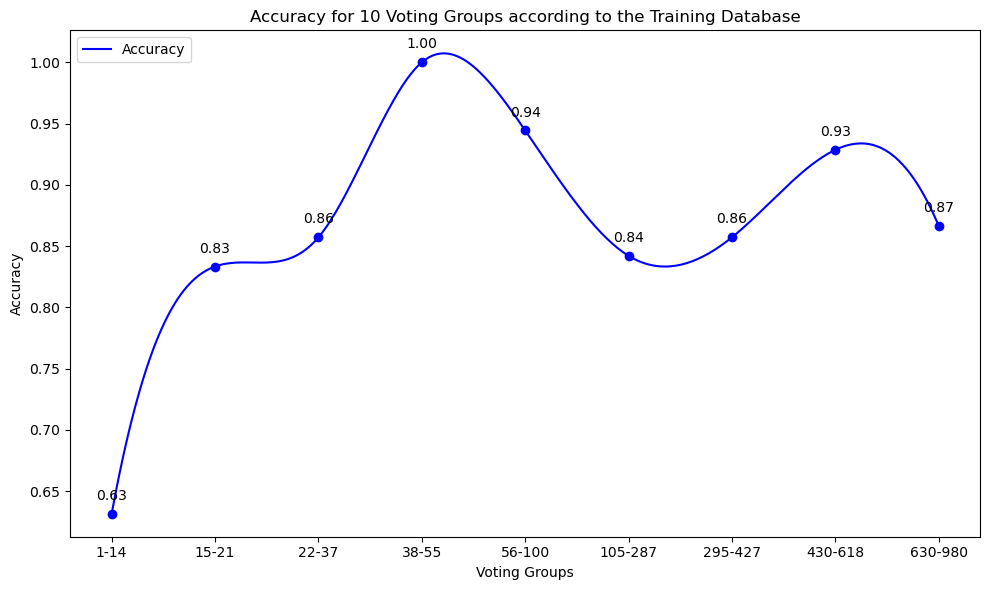

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Load the CSV file
df = pd.read_csv("data_plots/Groups_Accuracy_brazil.csv")

# Ensure data consistency
if df.isnull().values.any():
    raise ValueError("The CSV contains missing values, check the data integrity.")

# Generate the X-axis
x_values = range(len(df['Accuracy']))

# Smooth the curve using interpolation
xnew = np.linspace(0, len(df['Accuracy']) - 1, 300)
spl = make_interp_spline(x_values, df['Accuracy'], k=3)
y_smooth = spl(xnew)

# Plot the accuracy
plt.figure(figsize=(10, 6))
plt.plot(xnew, y_smooth, label='Accuracy', color='blue')

# Add scatter points
plt.scatter(x_values, df['Accuracy'], color='blue', marker='o')

# Annotate each point with its accuracy value
for i, txt in enumerate(df['Accuracy']):
    plt.annotate(f'{txt:.2f}', (i, txt), textcoords="offset points", xytext=(0, 10), ha='center')

plt.xticks(x_values, df['Votaciones'])  # Set X-axis labels
plt.xlabel("Voting Groups")
plt.ylabel("Accuracy")
plt.title("Accuracy for 10 Voting Groups according to the Training Database")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()